In [21]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
param_file = "../data/selected_params_halofit_unique.npy"
param_table = np.load(param_file)
param_table

from typing import Dict, Any

PARAM_NAMES = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

def load_cosmology_from_param_table(param_file: str, cosmo_index: int = 0) -> Dict[str, Any]:
    """
    Load cosmology parameters from a numpy file and return a dict of standard names.

    Supports:
    - numeric 2D arrays of shape (n_samples, 6)
    - numeric 1D arrays of length 6 (single sample)
    - structured numpy arrays with named fields (will attempt to map by PARAM_NAMES)

    Returned keys:
    - h, Oc (Omega_c), Ob (Omega_b), w (w0), wa, sigma8, Om, ns, H0
    """
    data = np.load(param_file, allow_pickle=True)

    # Structured dtype with names?
    if hasattr(data, "dtype") and data.dtype.names:
        # Try to map by latex labels or common equivalents
        def get_field(name_candidates):
            for nm in name_candidates:
                if nm in data.dtype.names:
                    return data[nm][cosmo_index] if data.ndim > 0 else data[nm].item()
            return None

        # common possible field names to check
        candidates = {
            "Omega_m": [r"$\\Omega_{m}$", "Omega_m", "Om", "omega_m", "omegam"],
            "sigma8": [r"$\\sigma_8$", "sigma8", "s8"],
            "w0": [r"$w_0$", "w0", "w"],
            "H0": [r"$H_0$", "H0", "h0"],
            "ns": [r"$n_s$", "ns"],
            "Omega_b": [r"$\\Omega_b$", "Omega_b", "Ob", "omegab"],
        }

        Omega_m = get_field(candidates["Omega_m"])
        sigma8 = get_field(candidates["sigma8"])
        w0 = get_field(candidates["w0"])
        H0 = get_field(candidates["H0"])
        ns = get_field(candidates["ns"])
        Omega_b = get_field(candidates["Omega_b"])

    else:
        # Numeric array: accept 1D length-6 or 2D samples x 6
        arr = np.asarray(data)
        if arr.ndim == 1 and arr.size == 6:
            row = arr
        elif arr.ndim == 2 and arr.shape[1] == 6:
            row = arr[cosmo_index]
        else:
            raise ValueError(f"Unexpected shape for param_table: {arr.shape}. Expect (6,) or (N,6).")

        Omega_m, sigma8, w0, H0, ns, Omega_b = row

    # Convert / compute standard quantities
    H0 = float(H0)
    h = H0 / 100.0
    Om = float(Omega_m)
    Ob = float(Omega_b)
    Oc = Om - Ob             # cold dark matter density
    w = float(w0)
    wa = 0.0                  # default unless present in table
    sigma8 = float(sigma8)
    ns = float(ns)

    return {
        "h": h,
        "Oc": Oc,
        "Ob": Ob,
        "w": w,
        "wa": wa,
        "sigma8": sigma8,
        "Om": Om,
        "ns": ns,
        "H0": H0,
    }

# Example usage:
# param_file = "/path/to/selected_params_halofit_unique.npy"
# params = load_cosmology_from_param_table(param_file, cosmo_index=5)
# h = params["h"]; Oc = params["Oc"]; Ob = params["Ob"]; ...

(1299, 500) (1299, 500) (1299,) (1299, 6) (1299, 500)
Using n(z) file: ../data/nz/nz_stage3_4_GRID.txt

--- Cosmology index: 0 ---
Ωm=0.3250  σ8=0.8375  w0=-1.062  h=0.7863  ns=1.0075  Ωb=0.0356
   Using scalar spectral index ns = 1.0075

Initialised Cosmology:
  h = 0.78625, Oc = 0.289375, Ob = 0.035625, w = -1.0623125, wa = 0.0, sigma8 = 0.8375
  k-range: [0.01, 0.5] with step dk = 0.005

the angles are:  0.005817764173314432  and  0.011635528346628864
      Variability: disabled


ERROR:2026-03-24 14:56:28,289:jax._src.callback:94: jax.pure_callback failed
Traceback (most recent call last):
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/site-packages/jax/_src/callback.py", line 92, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/site-packages/jax/_src/callback.py", line 70, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vtinnane/Documents/Codes/WALE/src/wale/FilterFunctions.py", line 39, in <lambda>
    [(-1.0) ** m / float(_math.factorial(m)) ** 2 for m in range(_N_BESSEL)]
                  ^^^^^^
NameError: name '_sp_j1' is not defined


ValueError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
  File "/home/vtinnane/miniforge3/envs/wale/lib/python3.12/asyncio/events.py", line 88, in 

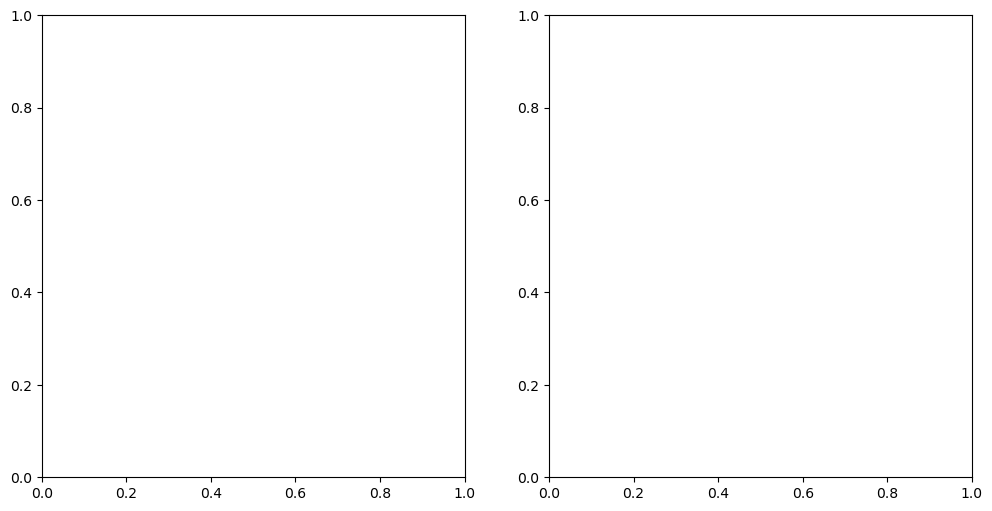

In [23]:
cosmogrid_kappa = np.load("../data/all_kappas_halofit_nobaryons_bin4.npy")
cosmogrid_l1norms = np.load("../data/all_l1_norms_halofit_nobaryons_bin4.npy")
cosmogrid_variances = np.load("../data/all_variances_halofit_nobaryons_bin4.npy")
cosmogrid_params = np.load("../data/selected_params_halofit.npy")

cosmogrid_snr = cosmogrid_kappa / (cosmogrid_variances[:, np.newaxis] ** 0.5)

print(cosmogrid_kappa.shape, cosmogrid_l1norms.shape, cosmogrid_variances.shape, cosmogrid_params.shape, cosmogrid_snr.shape)

id_zbin = 3  # Corresponds to the third redshift bin
nz_file = f"../data/nz/nz_stage3_{id_zbin+1}_GRID.txt"
print(f"Using n(z) file: {nz_file}")
theta1_input = 20.0  # Smoothing scale in arcmin
filter_type = 'tophat'

invalid_index = []
predictionl1 = []
predictionl1snr = []
cosmogrid = True

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for cosmoindex in range(0, 1):
    print(f"\n--- Cosmology index: {cosmoindex} ---")

    # --- Cosmology parameters ---
    Om     = cosmogrid_params[cosmoindex, 0]
    sigma8 = cosmogrid_params[cosmoindex, 1]
    w      = cosmogrid_params[cosmoindex, 2]
    h      = cosmogrid_params[cosmoindex, 3] / 100.
    ns     = cosmogrid_params[cosmoindex, 4]
    Ob     = cosmogrid_params[cosmoindex, 5]
    Oc     = Om - Ob
    wa     = 0.0

    print(f"Ωm={Om:.4f}  σ8={sigma8:.4f}  w0={w:.3f}  h={h:.4f}  ns={ns:.4f}  Ωb={Ob:.4f}")

    theta1 = theta1_input

    variables = InitialiseVariables(
        h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
        dk=0.005, kmin=1e-2, kmax=0.5,
        nz_file=nz_file, variability=False,
        theta1=theta1, nplanes=10, ns=ns,
    )

    # --- Variance ---
    variance = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)

    # sigmasq_map: sum over chi slices; get_sig_slice returns a JAX scalar → float()
    variables.sigmasq_map = float(np.sum(
        variables.dchi * (variables.lensingweights ** 2) * np.array([
            float(variance.get_sig_slice(z, chi * variables.theta1_radian, chi * variables.theta2_radian))
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    ))

    theory_sigmasq = compute_sigma_kappa_squared(
        theta1, variables.chis, variables.lensingweights,
        variables.redshifts, variables.cosmo.k, variables.cosmo.pnl,
        filter_type=filter_type, h=h,
    )

    # Recalibration: ratio of LDT variance to CosmoGRID simulation variance
    sigmasq_cosmogrid = float(cosmogrid_variances[cosmoindex])
    variables.recal_value = variables.sigmasq_map / cosmogrid_variances[cosmoindex]

    print(f"  sigmasq_map (LDT)  = {variables.sigmasq_map:.6e}")
    print(f"  sigmasq (PT)       = {theory_sigmasq:.6e}")
    print(f"  sigmasq_cosmogrid  = {sigmasq_cosmogrid:.6e}")
    print(f"  recal_value        = {variables.recal_value:.6f}")

    # --- Critical points ---
    smallest_positive, largest_negative = find_critical_points_for_cosmo(
        variables, variance, ngrid_critical=5, plot=False, min_z=0, max_z=5
    )
    if smallest_positive is not None and largest_negative is not None:
        variables.lambdas = np.linspace(largest_negative, smallest_positive, 20)

    # --- PDF ---
    kappa_grid = cosmogrid_kappa[cosmoindex]
    computed_PDF = computePDF(variables, variance, plot_scgf=False, kappa=kappa_grid)
    pdf_vals  = np.array(computed_PDF.pdf_values)   # ensure numpy
    kappa_vals = np.array(computed_PDF.kappa_values)

    # Normalize by CosmoGRID sigma (consistent for both theory and data)
    norm_kappa = kappa_vals / np.sqrt(sigmasq_cosmogrid)          # theory SNR axis
    snr        = cosmogrid_snr[cosmoindex]             # data SNR axis (same sigma)

    # L1 on SNR axis: interpolate theory onto data's SNR grid
    prediction_l1_kappa = np.abs(kappa_vals) * pdf_vals
    prediction_l1_snr   = CubicSpline(norm_kappa, prediction_l1_kappa)(snr)

    # Diagnostics
    pred_stats = get_moments(kappa_vals, pdf_vals)
    print(f"  pred_stats: mean={pred_stats[0]:.2e}, var={pred_stats[1]:.2e}, "
          f"s3={pred_stats[2]:.3f}, kurt={pred_stats[3]:.3f}, norm={pred_stats[4]:.3f}")

    if np.abs(pred_stats[0]) > 1e-6:
        invalid_index.append(cosmoindex)
        continue

    predictionl1snr.append(prediction_l1_snr)
    predictionl1.append(prediction_l1_kappa)

    # --- Plot SNR panel (ax[0]) ---
    ax[0].plot(snr, prediction_l1_snr, color='red', label='Theory')
    ax[0].plot(snr, cosmogrid_l1norms[cosmoindex], 'o', ms=1, color='blue', label='CosmoGRID')
    residual_snr = (prediction_l1_snr - cosmogrid_l1norms[cosmoindex]) / cosmogrid_l1norms[cosmoindex]
    mask_snr = (snr > -3) & (snr < 3)
    ax[0].plot(snr[mask_snr][::2], residual_snr[mask_snr][::2], 'x', color='green', label='Residual')

    # --- Plot κ panel (ax[1]) ---
    ax[1].plot(kappa_vals, prediction_l1_kappa, color='red')
    ax[1].plot(kappa_vals, cosmogrid_l1norms[cosmoindex], 'o', ms=1, color='blue')
    residual_l1 = (prediction_l1_kappa - cosmogrid_l1norms[cosmoindex]) / cosmogrid_l1norms[cosmoindex]
    mask_l1 = (kappa_vals > -2 * np.sqrt(sigmasq_cosmogrid)) & (kappa_vals < 2 * np.sqrt(sigmasq_cosmogrid))
    ax[1].plot(kappa_vals[mask_l1][::2], residual_l1[mask_l1][::2], 'x', color='green')

ax[0].axhline(0, color='gray', linestyle='dashed')
ax[0].set_xlabel(r'SNR $\kappa/\sigma$')
ax[0].set_ylabel(r'$|\kappa| P(\kappa)$')
ax[0].set_xlim(-6, 6)
ax[0].set_ylim(-0.05, 0.3)
# ax[0].legend(markerscale=3)

ax[1].axhline(0, color='gray', linestyle='dashed')
ax[1].set_xlabel(r'$\kappa$')
ax[1].set_ylabel(r'$|\kappa| P(\kappa)$')
ax[1].set_xlim(-0.015, 0.015)
ax[1].set_ylim(-0.05, 0.3)

plt.tight_layout()
plt.show()
print("Invalid indices:", invalid_index)


In [ ]:
def process_one_cosmology(cosmoindex):
    print(f"\n--- Cosmology index: {cosmoindex} ---")

    # --- Cosmology parameters ---
    Om     = cosmogrid_params[cosmoindex, 0]
    sigma8 = cosmogrid_params[cosmoindex, 1]
    w      = cosmogrid_params[cosmoindex, 2]
    h      = cosmogrid_params[cosmoindex, 3] / 100.
    ns     = cosmogrid_params[cosmoindex, 4]
    Ob     = cosmogrid_params[cosmoindex, 5]
    Oc     = Om - Ob
    wa     = 0.0

    theta1 = theta1_input

    # --- (1) Initialise variables ---
    variables = InitialiseVariables(
        h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
        dk=0.005, kmin=1e-2, kmax=0.5,
        nz_file=nz_file, variability=False,
        theta1=theta1, nplanes=10, ns=ns,
    )

    # --- (2) Variance ---
    variance = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)

    # get_sig_slice returns a JAX scalar → float() for safe numpy accumulation
    variables.sigmasq_map = float(np.sum(
        variables.dchi * (variables.lensingweights ** 2) * np.array([
            float(variance.get_sig_slice(z, chi * variables.theta1_radian, chi * variables.theta2_radian))
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    ))

    # Recalibration against CosmoGRID variance
    sigma_cosmogrid = float(np.sqrt(cosmogrid_variances[cosmoindex]))
    variables.recal_value = variables.sigmasq_map / cosmogrid_variances[cosmoindex]

    # --- (3) Critical points ---
    smallest_positive, largest_negative = find_critical_points_for_cosmo(
        variables, variance, ngrid_critical=25,
        plot=False, min_z=0, max_z=5,
    )
    if smallest_positive is not None and largest_negative is not None:
        variables.lambdas = np.linspace(largest_negative, smallest_positive, 20)

    # --- (4) PDF ---
    kappa_grid = cosmogrid_kappa[cosmoindex]
    computed_PDF = computePDF(variables, variance, plot_scgf=False, kappa=kappa_grid)
    pdf_vals   = np.array(computed_PDF.pdf_values)    # ensure numpy
    kappa_vals = np.array(computed_PDF.kappa_values)

    # SNR axis: use CosmoGRID sigma for both theory and data (consistent normalization)
    norm_kappa = kappa_vals / sigma_cosmogrid          # theory SNR
    snr        = cosmogrid_snr[cosmoindex]             # data SNR (same sigma)

    theory_l1_kappa = np.abs(kappa_vals) * pdf_vals
    prediction_l1   = CubicSpline(norm_kappa, theory_l1_kappa)(snr)

    pred_stats = get_moments(kappa_vals, pdf_vals)

    return {
        "index":           cosmoindex,
        "valid":           (np.abs(pred_stats[0]) < 1e-6),
        "kappa_vals":      kappa_vals,
        "pdf_vals":        pdf_vals,
        "snr":             snr,
        "sigma_cosmogrid": sigma_cosmogrid,
        "prediction_l1_snr":  prediction_l1,
        "theory_l1_kappa":    theory_l1_kappa,
        "pred_stats":      pred_stats,
    }


In [24]:
# JAX does not work safely with fork-based multiprocessing.
# Use threading (safe with JAX) or run serially (JAX parallelises internally via XLA).
from joblib import Parallel, delayed

results = Parallel(n_jobs=4, prefer="threads", verbose=10)(
    delayed(process_one_cosmology)(i)
    for i in range(100)
)


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


NameError: name 'process_one_cosmology' is not defined

In [ ]:
valid_results   = [r for r in results if r["valid"]]
invalid_indices = [r["index"] for r in results if not r["valid"]]
print(f"{len(valid_results)} valid, {len(invalid_indices)} invalid: {invalid_indices}")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for r in valid_results:
    idx            = r["index"]
    kappa_vals     = r["kappa_vals"]
    snr            = r["snr"]
    sigma_cg       = r["sigma_cosmogrid"]
    pred_l1_snr    = r["prediction_l1_snr"]   # theory L1 on SNR grid
    pred_l1_kappa  = r["theory_l1_kappa"]     # theory L1 on kappa grid

    # --- SNR panel ---
    ax[0].plot(snr, pred_l1_snr, 'r', alpha=0.6)
    ax[0].plot(cosmogrid_snr[idx], cosmogrid_l1norms[idx], 'o', ms=1, color='blue')
    residual_snr = (pred_l1_snr - cosmogrid_l1norms[idx]) / cosmogrid_l1norms[idx]
    mask_snr = (snr > -2) & (snr < 2)
    ax[0].plot(snr[mask_snr][::2], residual_snr[mask_snr][::2], 'x', color='green', ms=3)

    # --- κ panel ---
    # kappa_vals == cosmogrid_kappa[idx] (same grid passed to computePDF)
    ax[1].plot(kappa_vals, pred_l1_kappa, 'r', alpha=0.6)
    ax[1].plot(kappa_vals, cosmogrid_l1norms[idx], 'o', ms=1, color='blue')
    residual_l1 = (pred_l1_kappa - cosmogrid_l1norms[idx]) / cosmogrid_l1norms[idx]
    mask_l1 = (kappa_vals > -2 * sigma_cg) & (kappa_vals < 2 * sigma_cg)
    ax[1].plot(kappa_vals[mask_l1][::2], residual_l1[mask_l1][::2], 'x', color='green', ms=3)

ax[0].axhline(0, color='gray', linestyle='dashed')
ax[0].set_xlabel(r'SNR $\kappa/\sigma$')
ax[0].set_ylabel(r'$|\kappa| P(\kappa)$')
ax[0].set_xlim(-6, 6)
ax[0].set_ylim(-0.05, 0.3)

ax[1].axhline(0, color='gray', linestyle='dashed')
ax[1].set_xlabel(r'$\kappa$')
ax[1].set_ylabel(r'$|\kappa| P(\kappa)$')
ax[1].set_xlim(-0.015, 0.015)
ax[1].set_ylim(-0.05, 0.3)

plt.tight_layout()
plt.show()
